In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Generate the data

In [3]:
np.random.seed(42)

m = 100 #training examples
n = 2 #features
theta_real = np.array([[-1], [2], [3]])

x_1 = np.array(2 * np.random.rand(m, 1)) - 1
x_2 = np.array(2 * np.random.rand(m, 1)) - 1

X = np.hstack((np.ones((m,1)), x_1, x_2))

z = X @ theta_real
p = 1 / (1 + np.exp(-z))

y = (p > np.random.rand(m, 1)).astype(int).reshape((m,1)) #defines data as 1 or 0 with bernoulli noise

## Plot the data and the decision boundary line

The decidion boundary is the line formed by the points $(x_1, x_2)$ that solve the equation $-1 + 2x_1 + 3x_2 = 0$

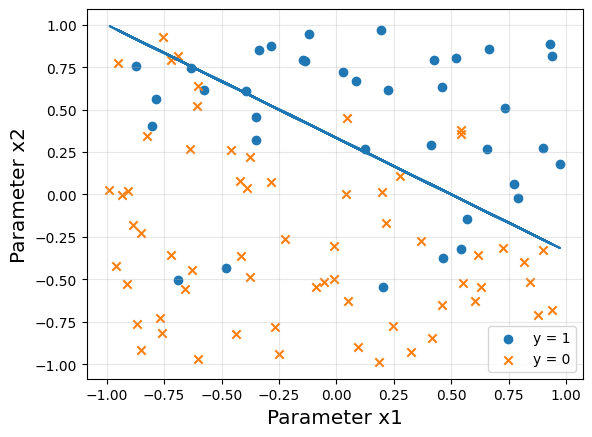

In [7]:
ones = y[:, 0] == 1
zeros = y[:, 0] == 0

plt.scatter(X[ones, 1], X[ones, 2], marker = 'o', label = 'y = 1')
plt.scatter(X[zeros, 1], X[zeros, 2], marker = 'x', label = 'y = 0')
plt.legend()

plt.plot(x_1, (1 - 2 * x_1) / 3) #decision boundary

plt.xlabel('Parameter x1', fontsize = 'x-large')
plt.ylabel('Parameter x2', fontsize = 'x-large')
plt.grid(alpha = 0.3)
plt.show()

## Apply Newton's Method

### The gradient of the log likelihood function

We have that $\log \mathcal{L}(\theta) = \sum_{i = 1}^m y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)})\log (1-h_\theta(x^{(i)}))$.

Consider now only one example, then $\nabla_\theta l(\theta) = \frac{\partial}{\partial \theta} y\log(h(x)) + (1-y)\log(1-h(x))$. To compute those derivatives we will use the chain rule, so it is best to first compute the derivatives of individual terms:

* $\frac{\partial}{\partial\theta}h(x) = \frac{\partial h}{\partial z}\frac{\partial z}{\partial \theta} = h(1-h)\frac{\partial z}{\partial \theta}$
* $\frac{\partial z}{\partial \theta} = \frac{\partial}{\partial \theta}\theta^Tx = x$

Using those results, we can go back to the gradient, obtaining $\nabla_\theta l(\theta) = \frac{y}{h} h(1-h)x - \left(\frac{1-y}{1-h}\right) h(1-h)x = x(y - h)$

Now for all training examples, we sum it up: $\nabla_\theta l(\theta) = \sum_{i = 1}^m x^{(i)}(y^{(i)} - h^{(i)})$. Considering one feature at a time, we have $\frac{\partial l(\theta)}{\partial \theta_j} = \sum_{i = 1}^m x_j^{(i)}(y^{(i)} - h^{(i)})$ with $j$ running up to $n$. Notice that this is similar to the result from linear regression, which leads to the final form of the gradient below:

$$
\nabla_\theta l(\theta) = X^T(\vec{y} - h_\theta(X\theta))
$$

### The hessian matrix
We have the definition of the hessian matrix as one where $H_{ij} = \frac{\partial^2}{\partial \theta_i\partial \theta_j}l(\theta)$. We start by taking the derivative of the gradient of $l$, that is: $\frac{\partial}{\partial \theta} \nabla l(\theta) = \frac{\partial}{\partial\theta} \sum_{i = 1}^m x^{(i)}(y^{(i)} - h^{(i)})$.

Again, we consider just one example at first, which gives $\frac{\partial}{\partial \theta} x(y - h) = x\frac{\partial}{\partial \theta} (y-h) = -x[h(1-h)x]$.

To turn that into an expression involving vectors, we must transpose the second $x$, since it is not possible to multiply two row vectors. Then we have $\frac{\partial}{\partial \theta} x(y - h) = -h(1-h)xx^T$.

For $m$ examples, we sum it up and notice a singular pattern. Define the matrix $R =$ diag$(h_i(1-h_i))$. The final form of the hessian matrix turns out to be the following:

$$
H = X^TRX
$$

In [8]:
def sigmoid(z):
    z = np.clip(z, -500, 500) #avoid too small or too big numbers that would cause an error
    return 1 / (1 + np.exp(-z))

def hypothesis(X, theta):
    return sigmoid(X @ theta)

def gradient_l(X, y, theta):
    h = hypothesis(X, theta)
    return X.T @ (y - h)

def hessian(X, theta):
    h = hypothesis(X, theta)
    r = h * (1 - h)
    R = np.diag(r.flatten())
    return X.T @ R @ X

In [9]:
theta0 = np.zeros((n+1, 1))
iterations = 5
gradients = []

theta = theta0
for _ in range(iterations):
    H = hessian(X, theta)
    gradient = gradient_l(X, y, theta)
    gradients.append(float(np.linalg.norm(gradient)))
    theta = theta + np.linalg.solve(H, gradient)

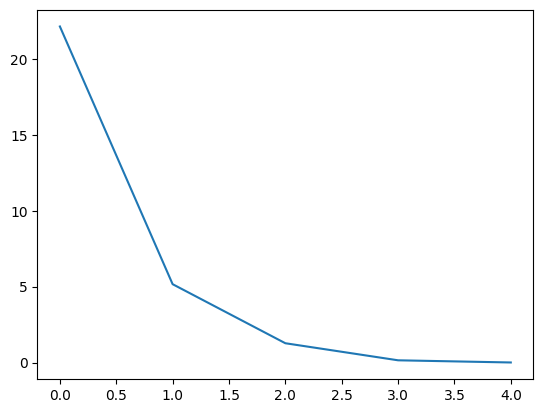

In [10]:
plt.plot(gradients)
plt.show()

## Results

Let us now use the parameter values found by the model to classify the data. Then, we compare the results from the model to the true values as to measure accuracy. We will also compare the results visually.

In [12]:
theta_model = theta
p_model = hypothesis(X, theta_model)
y_pred = (p_model > 0.5).astype(int)
accuracy = np.mean(y_pred == y)
print(f'Model has an accuracy of {accuracy * 100}%')

Model has an accuracy of 83.0%


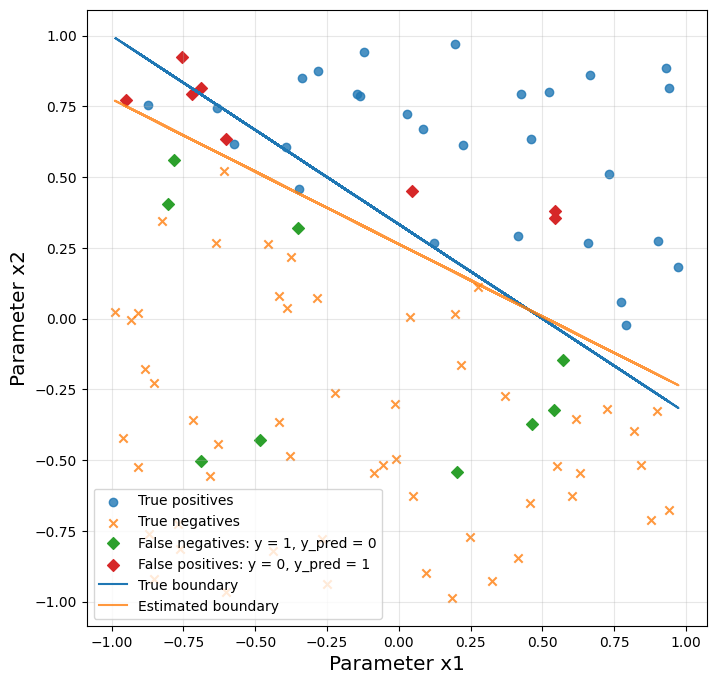

In [13]:
plt.figure(figsize = (8, 8))
correct_ones  = (y[:,0]==1) & (y_pred[:,0]==1)
correct_zeros = (y[:,0]==0) & (y_pred[:,0]==0)
false_negatives = (y[:,0]==1) & (y_pred[:,0]==0)
false_positives = (y[:,0]==0) & (y_pred[:,0]==1)
            
plt.scatter(X[correct_ones, 1], X[correct_ones, 2], marker = 'o', label = 'True positives', alpha = 0.8)
plt.scatter(X[correct_zeros, 1], X[correct_zeros, 2], marker = 'x', label = 'True negatives', alpha = 0.8)
plt.scatter(X[false_negatives, 1], X[false_negatives, 2], marker = 'D', label = 'False negatives: y = 1, y_pred = 0')
plt.scatter(X[false_positives, 1], X[false_positives, 2], marker = 'D', label = 'False positives: y = 0, y_pred = 1')


plt.plot(x_1, (1 - 2 * x_1) / 3, label = 'True boundary') 
plt.plot(x_1, -(theta_model[0] + theta_model[1] * x_1) / theta_model[2], label = 'Estimated boundary', alpha = 0.8)

plt.xlabel('Parameter x1', fontsize = 'x-large')
plt.ylabel('Parameter x2', fontsize = 'x-large')
plt.legend(loc = 'lower left')
plt.grid(alpha = 0.3)

plt.show()

The plot above can tell us several different things about the algorithm used to classify the data. Note that most of the misclassified datapoints are close to the boundary line, which is expected because those points have probabilities close to 0.5, which makes it harder to correctly classify them. The misclassified points far from the boundaries, in particular the false negatives on the bottom left of the plot, are most likely outliers. They stand out from the first plot as well, which indicates they are noisy datapoints.

The estimated decision boundary is slightly rotated when compared to true boundary. Such difference agrees with the misclassified points, especially on the top left: points that should be negative by the true decision boundary, but positive by the estimated boundary.

Overall, the model achieves about 83% accuracy. The remaining errors are mainly due to two factors: points near the decision boundary with inherently ambiguous classification, and a small number of outliers or noisy datapoints that do not follow the underlying distribution.